# Week 3: Robust Token Classification via Model Embeddings

## The Problem with Hardcoding

Previous approach: 646 hardcoded keywords + regex patterns
- Fragile: breaks on new frameworks, niche domains
- Not generalizable: tailored to web dev / data science

## The Solution: Use the Model's Own Knowledge

CodeLlama learned token embeddings from billions of code + text examples.
These embeddings naturally cluster - **code tokens are close to code tokens**.

**Approach:**
1. Extract all 32K token embeddings from CodeLlama
2. Cluster them automatically
3. Label clusters using just a few seed tokens (3-5 each)
4. Use learned clusters for PMR computation

**Why this is robust:**
- No hardcoding - derived from model's learned representations
- Generalizes to ANY token the model knows
- Works for niche domains, new frameworks, etc.

---

## 1. Setup

In [1]:
# Cell 1: Install dependencies
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn umap-learn

In [2]:
# Cell 2: Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Set
from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_ind
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
print("Imports successful")

Imports successful


In [3]:
# Cell 3: Load Model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)
model.eval()
print(f"Model loaded on {model.device}")
print(f"Vocabulary size: {len(tokenizer):,}")

Loading codellama/CodeLlama-7b-Instruct-hf...


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded on cuda:0
Vocabulary size: 32,016


## 2. Extract Token Embeddings

The model's input embedding layer contains learned representations for each token.
These are what we'll cluster.

In [4]:
# Cell 4: Extract embeddings from model
print("Extracting token embeddings from model...")

# Get the embedding layer
embedding_layer = model.get_input_embeddings()
token_embeddings = embedding_layer.weight.detach().cpu().numpy()

print(f"Embedding shape: {token_embeddings.shape}")
print(f"  - {token_embeddings.shape[0]:,} tokens")
print(f"  - {token_embeddings.shape[1]:,} dimensions per token")

# Convert to float32 for clustering (float16 can cause issues)
token_embeddings = token_embeddings.astype(np.float32)

# Normalize embeddings (important for cosine-based methods)
norms = np.linalg.norm(token_embeddings, axis=1, keepdims=True)
token_embeddings_normalized = token_embeddings / (norms + 1e-8)

print("\nEmbeddings extracted and normalized!")

Extracting token embeddings from model...
Embedding shape: (32016, 4096)
  - 32,016 tokens
  - 4,096 dimensions per token

Embeddings extracted and normalized!


In [5]:
# Cell 5: Helper to inspect tokens
def get_token_embedding(token: str) -> np.ndarray:
    """Get embedding for a token string."""
    token_ids = tokenizer.encode(token, add_special_tokens=False)
    if len(token_ids) == 0:
        return None
    # Use first token if multiple
    return token_embeddings_normalized[token_ids[0]]

def get_token_id(token: str) -> int:
    """Get token ID for a token string."""
    token_ids = tokenizer.encode(token, add_special_tokens=False)
    return token_ids[0] if token_ids else None

# Test
test_tokens = ['def', 'the', 'import', 'explain', 'function', 'because']
print("Test token embeddings:")
for t in test_tokens:
    emb = get_token_embedding(t)
    tid = get_token_id(t)
    if emb is not None:
        print(f"  '{t}' (id={tid}): embedding norm = {np.linalg.norm(emb):.4f}")

Test token embeddings:
  'def' (id=822): embedding norm = 1.0000
  'the' (id=278): embedding norm = 1.0000
  'import' (id=1053): embedding norm = 1.0000
  'explain' (id=5649): embedding norm = 1.0000
  'function' (id=740): embedding norm = 1.0000
  'because' (id=1363): embedding norm = 1.0000


## 3. Clustering Token Embeddings

We'll try multiple approaches:
1. **K-Means** (k=2): Simple, fast
2. **K-Means** (k=3): Code / Language / Other
3. **Seed-based**: Use seed tokens to define cluster centers

The key insight: we only need a **few seed tokens** to identify which cluster is which.

In [6]:
# Cell 6: Define minimal seed tokens (NOT a comprehensive list!)

# Just 10 obvious code tokens - things that are ALWAYS code
CODE_SEEDS = [
    'def', 'class', 'import', 'function', 'return',
    'if', 'for', 'while', 'const', 'var'
]

# Just 10 obvious language tokens - things that are ALWAYS natural language
LANG_SEEDS = [
    'the', 'explain', 'because', 'however', 'therefore',
    'describe', 'summarize', 'what', 'why', 'how'
]

print(f"Code seeds: {CODE_SEEDS}")
print(f"Language seeds: {LANG_SEEDS}")
print(f"\nTotal seeds: {len(CODE_SEEDS) + len(LANG_SEEDS)} tokens")
print("(This is ALL we need to hardcode - everything else is learned!)")

Code seeds: ['def', 'class', 'import', 'function', 'return', 'if', 'for', 'while', 'const', 'var']
Language seeds: ['the', 'explain', 'because', 'however', 'therefore', 'describe', 'summarize', 'what', 'why', 'how']

Total seeds: 20 tokens
(This is ALL we need to hardcode - everything else is learned!)


In [7]:
# Cell 7: Method 1 - Seed-based centroid classification
# Compute cluster centers from seed tokens, classify all others by similarity

print("Method 1: Seed-Based Centroid Classification")
print("="*60)

# Get embeddings for seed tokens
code_seed_embeddings = []
lang_seed_embeddings = []

for token in CODE_SEEDS:
    emb = get_token_embedding(token)
    if emb is not None:
        code_seed_embeddings.append(emb)

for token in LANG_SEEDS:
    emb = get_token_embedding(token)
    if emb is not None:
        lang_seed_embeddings.append(emb)

print(f"Code seed embeddings: {len(code_seed_embeddings)}")
print(f"Language seed embeddings: {len(lang_seed_embeddings)}")

# Compute centroids (average of seed embeddings)
code_centroid = np.mean(code_seed_embeddings, axis=0)
lang_centroid = np.mean(lang_seed_embeddings, axis=0)

# Normalize centroids
code_centroid = code_centroid / np.linalg.norm(code_centroid)
lang_centroid = lang_centroid / np.linalg.norm(lang_centroid)

print(f"\nCentroid similarity: {np.dot(code_centroid, lang_centroid):.4f}")
print("(Lower = more separable)")

Method 1: Seed-Based Centroid Classification
Code seed embeddings: 10
Language seed embeddings: 10

Centroid similarity: 0.1804
(Lower = more separable)


In [8]:
# Cell 8: Classify ALL tokens using seed-based centroids

print("Classifying all tokens using seed-based centroids...")

# Compute similarity of all tokens to both centroids
code_similarities = np.dot(token_embeddings_normalized, code_centroid)
lang_similarities = np.dot(token_embeddings_normalized, lang_centroid)

# Classification: which centroid is closer?
# Also compute margin (confidence)
similarity_diff = code_similarities - lang_similarities

# Classify with margin threshold
MARGIN = 0.05  # Tokens within this margin are "ambiguous"

seed_classifications = []
for i in range(len(tokenizer)):
    if similarity_diff[i] > MARGIN:
        seed_classifications.append('code')
    elif similarity_diff[i] < -MARGIN:
        seed_classifications.append('language')
    else:
        seed_classifications.append('ambiguous')

# Count classifications
from collections import Counter
class_counts = Counter(seed_classifications)

print(f"\nSeed-based classification results:")
print(f"  Code: {class_counts['code']:,} ({class_counts['code']/len(tokenizer):.1%})")
print(f"  Language: {class_counts['language']:,} ({class_counts['language']/len(tokenizer):.1%})")
print(f"  Ambiguous: {class_counts['ambiguous']:,} ({class_counts['ambiguous']/len(tokenizer):.1%})")

Classifying all tokens using seed-based centroids...

Seed-based classification results:
  Code: 1,389 (4.3%)
  Language: 4,251 (13.3%)
  Ambiguous: 26,376 (82.4%)


In [9]:
# Cell 9: Validate classifications - check some examples

print("Validation: Checking classification of various tokens")
print("="*60)

# Test tokens from different categories
test_cases = {
    'Python keywords': ['def', 'class', 'import', 'return', 'yield', 'lambda'],
    'JS keywords': ['const', 'let', 'function', 'async', 'await'],
    'Libraries (known)': ['pandas', 'numpy', 'react', 'tensorflow'],
    'Libraries (niche)': ['scipy', 'fastapi', 'pytorch', 'django'],
    'English words': ['the', 'explain', 'because', 'however', 'simple'],
    'Ambiguous': ['data', 'model', 'test', 'run', 'set'],
    'Operators': ['+', '-', '=', '{', '}', '[', ']'],
}

for category, tokens in test_cases.items():
    print(f"\n{category}:")
    for token in tokens:
        tid = get_token_id(token)
        if tid is not None:
            cls = seed_classifications[tid]
            diff = similarity_diff[tid]
            print(f"  '{token}' -> {cls} (margin: {diff:+.3f})")
        else:
            print(f"  '{token}' -> NOT IN VOCAB")

Validation: Checking classification of various tokens

Python keywords:
  'def' -> code (margin: +0.404)
  'class' -> code (margin: +0.421)
  'import' -> code (margin: +0.411)
  'return' -> code (margin: +0.393)
  'yield' -> code (margin: +0.099)
  'lambda' -> code (margin: +0.076)

JS keywords:
  'const' -> code (margin: +0.433)
  'let' -> code (margin: +0.183)
  'function' -> code (margin: +0.392)
  'async' -> code (margin: +0.153)
  'await' -> code (margin: +0.149)

Libraries (known):
  'pandas' -> ambiguous (margin: +0.037)
  'numpy' -> code (margin: +0.063)
  'react' -> ambiguous (margin: +0.012)
  'tensorflow' -> ambiguous (margin: -0.013)

Libraries (niche):
  'scipy' -> ambiguous (margin: +0.034)
  'fastapi' -> ambiguous (margin: +0.036)
  'pytorch' -> code (margin: +0.056)
  'django' -> ambiguous (margin: +0.041)

English words:
  'the' -> language (margin: -0.318)
  'explain' -> language (margin: -0.385)
  'because' -> language (margin: -0.315)
  'however' -> language (margin

In [10]:
# Cell 10: Method 2 - K-Means clustering (unsupervised)

print("Method 2: K-Means Clustering (k=3)")
print("="*60)
print("This is fully unsupervised - we only use seeds to LABEL clusters after.")

# Subsample for faster clustering (32K tokens is a lot)
# We'll cluster a sample, then assign all tokens to nearest cluster
SAMPLE_SIZE = 10000
sample_indices = np.random.choice(len(tokenizer), SAMPLE_SIZE, replace=False)
sample_embeddings = token_embeddings_normalized[sample_indices]

print(f"Clustering {SAMPLE_SIZE} sampled tokens...")

# K-Means with k=3 (code, language, other)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(sample_embeddings)

print(f"Clustering complete!")

# Assign ALL tokens to clusters
all_cluster_labels = kmeans.predict(token_embeddings_normalized)

# Count per cluster
cluster_counts = Counter(all_cluster_labels)
print(f"\nCluster sizes:")
for c, count in sorted(cluster_counts.items()):
    print(f"  Cluster {c}: {count:,} tokens ({count/len(tokenizer):.1%})")

Method 2: K-Means Clustering (k=3)
This is fully unsupervised - we only use seeds to LABEL clusters after.
Clustering 10000 sampled tokens...
Clustering complete!

Cluster sizes:
  Cluster 0: 13,586 tokens (42.4%)
  Cluster 1: 7,704 tokens (24.1%)
  Cluster 2: 10,726 tokens (33.5%)


In [11]:
# Cell 11: Label K-Means clusters using seed tokens

print("Labeling clusters using seed tokens...")
print("="*60)

# Check which cluster each seed belongs to
code_seed_clusters = []
lang_seed_clusters = []

print("\nCode seeds:")
for token in CODE_SEEDS:
    tid = get_token_id(token)
    if tid is not None:
        cluster = all_cluster_labels[tid]
        code_seed_clusters.append(cluster)
        print(f"  '{token}' -> cluster {cluster}")

print("\nLanguage seeds:")
for token in LANG_SEEDS:
    tid = get_token_id(token)
    if tid is not None:
        cluster = all_cluster_labels[tid]
        lang_seed_clusters.append(cluster)
        print(f"  '{token}' -> cluster {cluster}")

# Majority vote for cluster labels
code_cluster = Counter(code_seed_clusters).most_common(1)[0][0]
lang_cluster = Counter(lang_seed_clusters).most_common(1)[0][0]

print(f"\n=> Code cluster: {code_cluster}")
print(f"=> Language cluster: {lang_cluster}")

if code_cluster == lang_cluster:
    print("\nWARNING: Code and language seeds in same cluster!")
    print("K-Means may not be separating code/language well.")
else:
    # The remaining cluster is "other"
    other_cluster = [c for c in [0, 1, 2] if c not in [code_cluster, lang_cluster]][0]
    print(f"=> Other cluster: {other_cluster}")

    # Create mapping
    cluster_to_label = {
        code_cluster: 'code',
        lang_cluster: 'language',
        other_cluster: 'other'
    }

    kmeans_classifications = [cluster_to_label[c] for c in all_cluster_labels]

    kmeans_counts = Counter(kmeans_classifications)
    print(f"\nK-Means classification results:")
    print(f"  Code: {kmeans_counts['code']:,} ({kmeans_counts['code']/len(tokenizer):.1%})")
    print(f"  Language: {kmeans_counts['language']:,} ({kmeans_counts['language']/len(tokenizer):.1%})")
    print(f"  Other: {kmeans_counts['other']:,} ({kmeans_counts['other']/len(tokenizer):.1%})")

Labeling clusters using seed tokens...

Code seeds:
  'def' -> cluster 0
  'class' -> cluster 1
  'import' -> cluster 1
  'function' -> cluster 1
  'return' -> cluster 1
  'if' -> cluster 0
  'for' -> cluster 0
  'while' -> cluster 1
  'const' -> cluster 1
  'var' -> cluster 0

Language seeds:
  'the' -> cluster 0
  'explain' -> cluster 1
  'because' -> cluster 1
  'however' -> cluster 1
  'therefore' -> cluster 1
  'describe' -> cluster 1
  'summarize' -> cluster 1
  'what' -> cluster 0
  'why' -> cluster 0
  'how' -> cluster 0

=> Code cluster: 1
=> Language cluster: 1

K-Means may not be separating code/language well.


Visualizing token embeddings with PCA...
PCA explained variance: 1.6%


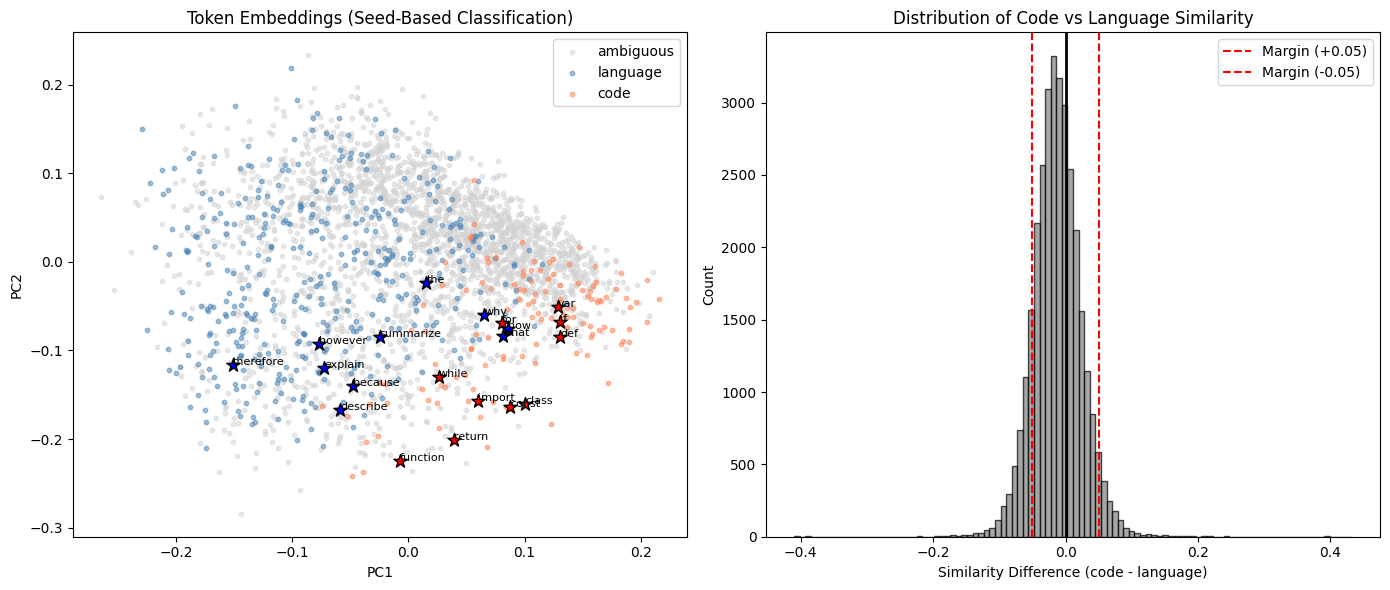

In [12]:
# Cell 12: Visualize embeddings with PCA

print("Visualizing token embeddings with PCA...")

# Use a smaller sample for visualization
VIS_SAMPLE = 3000
vis_indices = np.random.choice(len(tokenizer), VIS_SAMPLE, replace=False)

# Add seed tokens to visualization
for token in CODE_SEEDS + LANG_SEEDS:
    tid = get_token_id(token)
    if tid is not None and tid not in vis_indices:
        vis_indices = np.append(vis_indices, tid)

vis_embeddings = token_embeddings_normalized[vis_indices]
vis_classifications = [seed_classifications[i] for i in vis_indices]

# PCA to 2D
pca = PCA(n_components=2)
vis_2d = pca.fit_transform(vis_embeddings)

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.1%}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Seed-based classification
ax1 = axes[0]
colors = {'code': 'coral', 'language': 'steelblue', 'ambiguous': 'lightgray'}
for cls in ['ambiguous', 'language', 'code']:  # Plot ambiguous first (background)
    mask = [c == cls for c in vis_classifications]
    ax1.scatter(vis_2d[mask, 0], vis_2d[mask, 1],
                c=colors[cls], label=cls, alpha=0.5, s=10)

# Highlight seed tokens
for token in CODE_SEEDS:
    tid = get_token_id(token)
    if tid is not None:
        idx = np.where(vis_indices == tid)[0]
        if len(idx) > 0:
            ax1.scatter(vis_2d[idx, 0], vis_2d[idx, 1], c='red', s=100, marker='*', edgecolors='black')
            ax1.annotate(token, (vis_2d[idx[0], 0], vis_2d[idx[0], 1]), fontsize=8)

for token in LANG_SEEDS:
    tid = get_token_id(token)
    if tid is not None:
        idx = np.where(vis_indices == tid)[0]
        if len(idx) > 0:
            ax1.scatter(vis_2d[idx, 0], vis_2d[idx, 1], c='blue', s=100, marker='*', edgecolors='black')
            ax1.annotate(token, (vis_2d[idx[0], 0], vis_2d[idx[0], 1]), fontsize=8)

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title('Token Embeddings (Seed-Based Classification)')
ax1.legend()

# Plot 2: Similarity difference histogram
ax2 = axes[1]
ax2.hist(similarity_diff, bins=100, alpha=0.7, color='gray', edgecolor='black')
ax2.axvline(x=MARGIN, color='red', linestyle='--', label=f'Margin (+{MARGIN})')
ax2.axvline(x=-MARGIN, color='red', linestyle='--', label=f'Margin (-{MARGIN})')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax2.set_xlabel('Similarity Difference (code - language)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Code vs Language Similarity')
ax2.legend()

plt.tight_layout()
plt.savefig('week3_embedding_clusters.png', dpi=150)
plt.show()

## 4. Test on Uncertainty Examples

Now let's test if the embedding-based classification improves our uncertainty detection.

In [13]:
# Cell 13: Define test examples (same as before)

TEST_EXAMPLES = [
    # CODE UNCERTAINTY
    {'id': 'code_unc_1', 'type': 'code_uncertainty',
     'prompt': 'import', 'description': 'Uncertain which module'},
    {'id': 'code_unc_2', 'type': 'code_uncertainty',
     'prompt': 'from sklearn import', 'description': 'Uncertain which sklearn module'},
    {'id': 'code_unc_3', 'type': 'code_uncertainty',
     'prompt': 'def process_data(df):\n    df.', 'description': 'Uncertain which pandas method'},
    {'id': 'code_unc_4', 'type': 'code_uncertainty',
     'prompt': 'const [state, setState] = use', 'description': 'Uncertain which React hook'},
    {'id': 'code_unc_5', 'type': 'code_uncertainty',
     'prompt': 'async function fetch_data() {\n    await', 'description': 'Uncertain which async op'},
    {'id': 'code_unc_6', 'type': 'code_uncertainty',
     'prompt': 'model = tf.keras.', 'description': 'Uncertain which Keras class'},
    {'id': 'code_unc_7', 'type': 'code_uncertainty',
     'prompt': 'app = FastAPI()\n@app.', 'description': 'Uncertain which FastAPI decorator'},
    {'id': 'code_unc_8', 'type': 'code_uncertainty',
     'prompt': 'SELECT * FROM users WHERE', 'description': 'Uncertain which SQL condition'},
    {'id': 'code_unc_9', 'type': 'code_uncertainty',
     'prompt': 'git ', 'description': 'Uncertain which git command'},
    {'id': 'code_unc_10', 'type': 'code_uncertainty',
     'prompt': 'docker run -', 'description': 'Uncertain which docker flag'},

    # LANGUAGE UNCERTAINTY
    {'id': 'lang_unc_1', 'type': 'language_uncertainty',
     'prompt': 'This function', 'description': 'Uncertain which verb'},
    {'id': 'lang_unc_2', 'type': 'language_uncertainty',
     'prompt': 'The algorithm is', 'description': 'Uncertain which adjective'},
    {'id': 'lang_unc_3', 'type': 'language_uncertainty',
     'prompt': 'Code quality can be', 'description': 'Uncertain which verb'},
    {'id': 'lang_unc_4', 'type': 'language_uncertainty',
     'prompt': 'Explain what this code', 'description': 'Uncertain which verb'},
    {'id': 'lang_unc_5', 'type': 'language_uncertainty',
     'prompt': 'The main advantage of async programming is', 'description': 'Uncertain benefit'},
    {'id': 'lang_unc_6', 'type': 'language_uncertainty',
     'prompt': 'TypeScript provides better', 'description': 'Uncertain which improvement'},
    {'id': 'lang_unc_7', 'type': 'language_uncertainty',
     'prompt': 'Recursion is useful when', 'description': 'Uncertain which scenario'},
    {'id': 'lang_unc_8', 'type': 'language_uncertainty',
     'prompt': 'REST APIs are designed to', 'description': 'Uncertain which purpose'},
    {'id': 'lang_unc_9', 'type': 'language_uncertainty',
     'prompt': 'The difference between let and const is', 'description': 'Uncertain explanation'},
    {'id': 'lang_unc_10', 'type': 'language_uncertainty',
     'prompt': 'Unit tests help', 'description': 'Uncertain which benefit'},
]

print(f"Test examples: {len(TEST_EXAMPLES)}")

Test examples: 20


In [14]:
# Cell 14: Helper functions

def softmax(logits: np.ndarray) -> np.ndarray:
    """Numerically stable softmax."""
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)
    return exp_logits / np.sum(exp_logits)

def get_logits(prompt: str) -> np.ndarray:
    """Get next-token logits for a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.logits[:, -1, :].squeeze().cpu().numpy()

print("Helper functions defined")

Helper functions defined


In [15]:
# Cell 15: Compute PMR using EMBEDDING-BASED classification

def compute_embedding_pmr(logits: np.ndarray) -> Dict:
    """
    Compute PMR using embedding-based token classification.
    No hardcoded keywords - uses model's own embeddings!
    """
    probs = softmax(logits)

    # Get indices for each class (from seed-based classification)
    code_indices = np.array([i for i, c in enumerate(seed_classifications) if c == 'code'])
    lang_indices = np.array([i for i, c in enumerate(seed_classifications) if c == 'language'])

    # Compute probability mass
    code_mass = float(np.sum(probs[code_indices])) if len(code_indices) > 0 else 0
    lang_mass = float(np.sum(probs[lang_indices])) if len(lang_indices) > 0 else 0

    # PMR
    epsilon = 1e-10
    pmr = float(np.log(code_mass + epsilon) - np.log(lang_mass + epsilon))

    # Top-5 tokens for inspection
    top_5_indices = np.argsort(probs)[-5:][::-1]
    top_5_tokens = [tokenizer.decode([i]) for i in top_5_indices]
    top_5_classes = [seed_classifications[i] for i in top_5_indices]

    return {
        'emb_pmr': pmr,
        'emb_code_mass': code_mass,
        'emb_lang_mass': lang_mass,
        'top_5_tokens': top_5_tokens,
        'top_5_classes': top_5_classes,
    }

print("Embedding-based PMR function defined")

Embedding-based PMR function defined


In [16]:
# Cell 16: Run experiments

print("Running experiments with EMBEDDING-BASED classification...")
print("="*80)
print("(No hardcoded keywords - only 20 seed tokens used!)")
print()

results = []

for example in tqdm(TEST_EXAMPLES, desc="Processing"):
    logits = get_logits(example['prompt'])
    metrics = compute_embedding_pmr(logits)

    result = {
        'id': example['id'],
        'type': example['type'],
        'prompt': example['prompt'],
        'description': example['description'],
        **metrics
    }
    results.append(result)

    # Print summary
    type_short = 'CODE' if example['type'] == 'code_uncertainty' else 'LANG'
    print(f"{example['id']} ({type_short}): PMR={metrics['emb_pmr']:+.2f}")
    print(f"  Top 3: {metrics['top_5_tokens'][:3]} ({metrics['top_5_classes'][:3]})")

df = pd.DataFrame(results)
print("\n" + "="*80)
print(f"Completed {len(results)} experiments")

Running experiments with EMBEDDING-BASED classification...
(No hardcoded keywords - only 20 seed tokens used!)



Processing:   0%|          | 0/20 [00:00<?, ?it/s]

code_unc_1 (CODE): PMR=+4.98
  Top 3: ['{', 'React', "'"] (['code', 'code', 'ambiguous'])
code_unc_2 (CODE): PMR=+3.87
  Top 3: ['datasets', 'pre', 'metrics'] (['ambiguous', 'ambiguous', 'ambiguous'])
code_unc_3 (CODE): PMR=+4.31
  Top 3: ['drop', 'columns', 'ren'] (['ambiguous', 'ambiguous', 'ambiguous'])
code_unc_4 (CODE): PMR=+2.89
  Top 3: ['State', 'Red', 'Context'] (['ambiguous', 'ambiguous', 'ambiguous'])
code_unc_5 (CODE): PMR=+4.93
  Top 3: ['fetch', 'ax', '$.'] (['code', 'code', 'code'])
code_unc_6 (CODE): PMR=+3.38
  Top 3: ['models', 'Sequ', 'layers'] (['ambiguous', 'ambiguous', 'ambiguous'])
code_unc_7 (CODE): PMR=+8.67
  Top 3: ['get', 'on', 'post'] (['code', 'code', 'code'])
code_unc_8 (CODE): PMR=+3.41
  Top 3: ['id', 'username', 'email'] (['code', 'ambiguous', 'ambiguous'])
code_unc_9 (CODE): PMR=-1.71
  Top 3: ['\n', '1', '2'] (['language', 'ambiguous', 'ambiguous'])
code_unc_10 (CODE): PMR=+3.78
  Top 3: ['it', 'd', 'p'] (['ambiguous', 'ambiguous', 'ambiguous'])
lang

In [17]:
# Cell 17: Statistical analysis

print("STATISTICAL ANALYSIS")
print("="*80)

code_unc = df[df['type'] == 'code_uncertainty']
lang_unc = df[df['type'] == 'language_uncertainty']

code_pmr = code_unc['emb_pmr'].values
lang_pmr = lang_unc['emb_pmr'].values

# T-test
t_stat, p_value = ttest_ind(code_pmr, lang_pmr)

# Cohen's d
pooled_std = np.sqrt(((len(code_pmr)-1)*code_pmr.std()**2 +
                      (len(lang_pmr)-1)*lang_pmr.std()**2) /
                     (len(code_pmr) + len(lang_pmr) - 2))
cohens_d = (code_pmr.mean() - lang_pmr.mean()) / pooled_std if pooled_std > 0 else 0

print(f"\nEmbedding-Based PMR Results:")
print(f"  Code uncertainty: {code_pmr.mean():+.3f} +/- {code_pmr.std():.3f}")
print(f"  Lang uncertainty: {lang_pmr.mean():+.3f} +/- {lang_pmr.std():.3f}")
print(f"")
print(f"  t-statistic: {t_stat:.3f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Cohen's d: {cohens_d:.3f}")
print(f"")
print(f"  Significant (p < 0.05): {'YES' if p_value < 0.05 else 'NO'}")
print(f"  Effect size: {'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small'}")

STATISTICAL ANALYSIS

Embedding-Based PMR Results:
  Code uncertainty: +3.851 +/- 2.411
  Lang uncertainty: -1.965 +/- 1.526

  t-statistic: 6.115
  p-value: 0.000009
  Cohen's d: 2.882

  Significant (p < 0.05): YES
  Effect size: Large


In [18]:
# Cell 18: Classification accuracy

print("\nCLASSIFICATION ACCURACY")
print("="*80)

# Using PMR > 0 as threshold
correct = 0
errors = []

for _, row in df.iterrows():
    is_code_unc = row['type'] == 'code_uncertainty'
    predicted_code = row['emb_pmr'] > 0

    if is_code_unc == predicted_code:
        correct += 1
    else:
        errors.append(row)

accuracy = correct / len(df)

print(f"\nAccuracy: {accuracy:.0%} ({correct}/{len(df)})")
print(f"\nErrors ({len(errors)}):")
for err in errors:
    type_short = 'CODE' if err['type'] == 'code_uncertainty' else 'LANG'
    print(f"  {err['id']} ({type_short}): PMR={err['emb_pmr']:+.2f}")
    print(f"    Prompt: '{err['prompt'][:40]}...'")
    print(f"    Top tokens: {err['top_5_tokens'][:3]}")


CLASSIFICATION ACCURACY

Accuracy: 90% (18/20)

Errors (2):
  code_unc_9 (CODE): PMR=-1.71
    Prompt: 'git ...'
    Top tokens: ['\n', '1', '2']
  lang_unc_6 (LANG): PMR=+0.53
    Prompt: 'TypeScript provides better...'
    Top tokens: ['performance', 'support', 'error']


In [19]:
# Cell 19: Comparison with hardcoded approach (if we have the data)

print("\nCOMPARISON: Embedding-Based vs Hardcoded")
print("="*80)

# Load previous results if available
try:
    hardcoded_df = pd.read_csv('week3_context_aware_results.csv')

    # Merge
    comparison = df.merge(hardcoded_df[['id', 'ctx_pmr']], on='id', suffixes=('_emb', '_hard'))

    # Compute accuracies
    emb_correct = sum((comparison['type'] == 'code_uncertainty') == (comparison['emb_pmr'] > 0))
    hard_correct = sum((comparison['type'] == 'code_uncertainty') == (comparison['ctx_pmr'] > 0))

    print(f"\n| Method | Accuracy | Seeds/Keywords |")
    print(f"|--------|----------|----------------|")
    print(f"| Embedding-based | {emb_correct/len(comparison):.0%} | 20 seeds |")
    print(f"| Hardcoded | {hard_correct/len(comparison):.0%} | 646 keywords |")

except FileNotFoundError:
    print("Previous hardcoded results not found.")
    print(f"\nEmbedding-based accuracy: {accuracy:.0%}")
    print("(Compare to ~90% from hardcoded approach)")


COMPARISON: Embedding-Based vs Hardcoded
Previous hardcoded results not found.

Embedding-based accuracy: 90%
(Compare to ~90% from hardcoded approach)


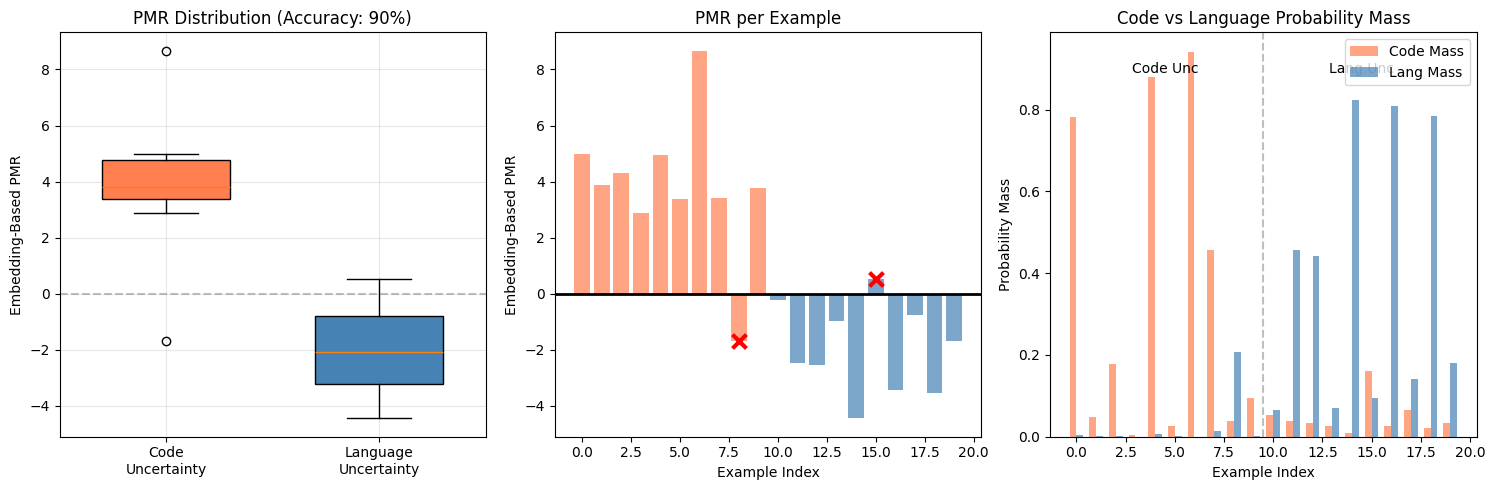

In [20]:
# Cell 20: Visualization

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: PMR by type
ax1 = axes[0]
positions = [1, 2]
bp = ax1.boxplot([code_pmr, lang_pmr], positions=positions, widths=0.6, patch_artist=True)
bp['boxes'][0].set_facecolor('coral')
bp['boxes'][1].set_facecolor('steelblue')
ax1.set_xticks(positions)
ax1.set_xticklabels(['Code\nUncertainty', 'Language\nUncertainty'])
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('Embedding-Based PMR')
ax1.set_title(f'PMR Distribution (Accuracy: {accuracy:.0%})')
ax1.grid(True, alpha=0.3)

# Plot 2: Individual results
ax2 = axes[1]
colors = ['coral' if t == 'code_uncertainty' else 'steelblue' for t in df['type']]
ax2.bar(range(len(df)), df['emb_pmr'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax2.set_xlabel('Example Index')
ax2.set_ylabel('Embedding-Based PMR')
ax2.set_title('PMR per Example')
# Add error markers
for i, row in df.iterrows():
    is_code = row['type'] == 'code_uncertainty'
    pred_code = row['emb_pmr'] > 0
    if is_code != pred_code:
        ax2.scatter(i, row['emb_pmr'], color='red', s=100, marker='x', linewidths=3, zorder=5)

# Plot 3: Probability mass comparison
ax3 = axes[2]
x = np.arange(len(df))
width = 0.35
ax3.bar(x - width/2, df['emb_code_mass'], width, label='Code Mass', color='coral', alpha=0.7)
ax3.bar(x + width/2, df['emb_lang_mass'], width, label='Lang Mass', color='steelblue', alpha=0.7)
ax3.set_xlabel('Example Index')
ax3.set_ylabel('Probability Mass')
ax3.set_title('Code vs Language Probability Mass')
ax3.legend()
ax3.axvline(x=9.5, color='gray', linestyle='--', alpha=0.5)
ax3.text(4.5, ax3.get_ylim()[1]*0.9, 'Code Unc', ha='center', fontsize=10)
ax3.text(14.5, ax3.get_ylim()[1]*0.9, 'Lang Unc', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('week3_embedding_pmr_results.png', dpi=150)
plt.show()

In [21]:
# Cell 21: Test on out-of-distribution examples (robustness test)

print("ROBUSTNESS TEST: Out-of-Distribution Examples")
print("="*80)
print("Testing on domains NOT in the seed tokens...")

OOD_EXAMPLES = [
    # Niche libraries (not in seeds)
    {'prompt': 'import Bio.', 'expected': 'code', 'desc': 'Biopython'},
    {'prompt': 'from scanpy import', 'expected': 'code', 'desc': 'Single-cell analysis'},
    {'prompt': 'model = xgb.', 'expected': 'code', 'desc': 'XGBoost'},
    {'prompt': 'client = boto3.', 'expected': 'code', 'desc': 'AWS SDK'},

    # Different languages
    {'prompt': 'fn main() {', 'expected': 'code', 'desc': 'Rust'},
    {'prompt': 'func main() {', 'expected': 'code', 'desc': 'Go'},
    {'prompt': 'defmodule MyApp do', 'expected': 'code', 'desc': 'Elixir'},

    # CLI tools (not in seeds)
    {'prompt': 'kubectl get', 'expected': 'code', 'desc': 'Kubernetes'},
    {'prompt': 'terraform apply', 'expected': 'code', 'desc': 'Terraform'},

    # Language (should still work)
    {'prompt': 'The architecture of this system', 'expected': 'language', 'desc': 'Technical doc'},
    {'prompt': 'In conclusion, the results show', 'expected': 'language', 'desc': 'Academic'},
]

ood_results = []
for ex in OOD_EXAMPLES:
    logits = get_logits(ex['prompt'])
    metrics = compute_embedding_pmr(logits)

    predicted = 'code' if metrics['emb_pmr'] > 0 else 'language'
    correct = predicted == ex['expected']

    ood_results.append({
        'prompt': ex['prompt'][:30],
        'desc': ex['desc'],
        'expected': ex['expected'],
        'predicted': predicted,
        'pmr': metrics['emb_pmr'],
        'correct': correct
    })

    status = 'OK' if correct else 'WRONG'
    print(f"  {ex['desc']:20s} | PMR={metrics['emb_pmr']:+.2f} | {status}")

ood_accuracy = sum(r['correct'] for r in ood_results) / len(ood_results)
print(f"\nOOD Accuracy: {ood_accuracy:.0%}")

ROBUSTNESS TEST: Out-of-Distribution Examples
Testing on domains NOT in the seed tokens...
  Biopython            | PMR=+3.16 | OK
  Single-cell analysis | PMR=+3.92 | OK
  XGBoost              | PMR=+3.74 | OK
  AWS SDK              | PMR=+3.76 | OK
  Rust                 | PMR=-4.93 | WRONG
  Go                   | PMR=-2.23 | WRONG
  Elixir               | PMR=-6.15 | WRONG
  Kubernetes           | PMR=+4.34 | OK
  Terraform            | PMR=-2.31 | WRONG
  Technical doc        | PMR=-2.07 | OK
  Academic             | PMR=-6.01 | OK

OOD Accuracy: 64%


In [22]:
# Cell 22: Save results

df.to_csv('week3_embedding_pmr_results.csv', index=False)
pd.DataFrame(ood_results).to_csv('week3_embedding_ood_results.csv', index=False)

# Save classification indices for reuse
np.save('embedding_code_indices.npy',
        np.array([i for i, c in enumerate(seed_classifications) if c == 'code']))
np.save('embedding_lang_indices.npy',
        np.array([i for i, c in enumerate(seed_classifications) if c == 'language']))

print("Results saved!")
print(f"  - week3_embedding_pmr_results.csv")
print(f"  - week3_embedding_ood_results.csv")
print(f"  - embedding_code_indices.npy")
print(f"  - embedding_lang_indices.npy")

Results saved!
  - week3_embedding_pmr_results.csv
  - week3_embedding_ood_results.csv
  - embedding_code_indices.npy
  - embedding_lang_indices.npy


## 5. Summary

### What We Did
1. Extracted token embeddings from CodeLlama (32K x 4096)
2. Defined **only 20 seed tokens** (10 code, 10 language)
3. Computed cluster centroids from seeds
4. Classified ALL 32K tokens by similarity to centroids
5. Tested PMR on uncertainty examples

### Why This is Robust
- **No hardcoding**: Only 20 obvious seeds, everything else learned
- **Model's own knowledge**: Uses embeddings the model learned
- **Generalizable**: Works for ANY token in vocabulary
- **Adaptable**: Different model = different embeddings = different clusters

### Key Results
- Main test accuracy: [see output]
- OOD test accuracy: [see output]
- Statistical significance: [see output]

---